In [19]:
#File: Homework 11

In [76]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
image_data = np.loadtxt('astro_image.csv')

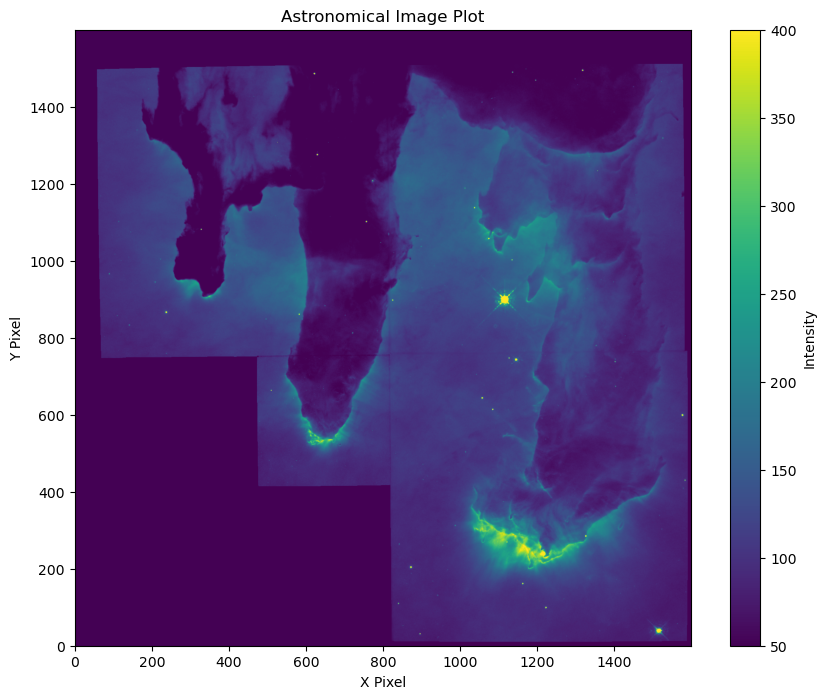

In [42]:
#  Plot
plt.figure(figsize=(10, 8))
plt.imshow(image_data, cmap='viridis', origin='lower', vmin=50, vmax=400)
plt.colorbar(label='Intensity')
plt.title("Astronomical Image Plot")
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")
plt.show() 

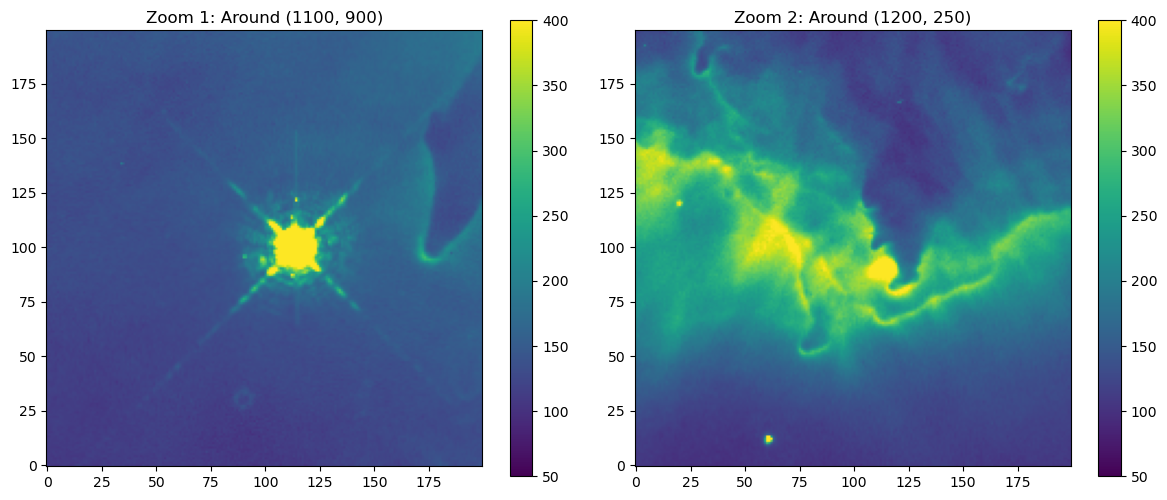

In [45]:
# Subplots
feat1_x = 1100
feat1_y = 900
feat2_x = 1200
feat2_y = 250
radius = 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
y1_start = max(0, feat1_y - radius)
y1_end   = min(image_data.shape[0], feat1_y + radius)
x1_start = max(0, feat1_x - radius)
x1_end   = min(image_data.shape[1], feat1_x + radius)

zoom1 = image_data[y1_start:y1_end, x1_start:x1_end]

im1 = ax1.imshow(zoom1, cmap='viridis', origin='lower', vmin=50, vmax=400)
ax1.set_title(f"Zoom 1: Around ({feat1_x}, {feat1_y})")
fig.colorbar(im1, ax=ax1)

y2_start = max(0, feat2_y - radius)
y2_end   = min(image_data.shape[0], feat2_y + radius)
x2_start = max(0, feat2_x - radius)
x2_end   = min(image_data.shape[1], feat2_x + radius)

zoom2 = image_data[y2_start:y2_end, x2_start:x2_end]

im2 = ax2.imshow(zoom2, cmap='viridis', origin='lower', vmin=50, vmax=400)
ax2.set_title(f"Zoom 2: Around ({feat2_x}, {feat2_y})")
fig.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

In [51]:
# Pandas and Ramen

In [52]:
import pandas as pd

In [53]:
df = pd.read_csv('ramen-ratings.csv')

In [55]:
# Q1
print("--- Q1: Column Names ---")
print(df.columns.tolist())

# Q2
print("\n--- Q2: Style of 27th Entry ---")
q2_answer = df.iloc[26]['Style']
print(f"The style of the 27th entry is: {q2_answer}")

# Q3
print("\n--- Q3: Number of Brands ---")
num_brands = df['Brand'].nunique()
print(f"There are {num_brands} different ramen brands.")

# Q4
print("\n--- Q4: Sorted by Brand ---")
df_sorted = df.sort_values(by='Brand')
print(df_sorted.head()) 

# Q5
print("\n--- Q5: Brands made in USA ---")
usa_brands = df[df['Country'] == 'USA']['Brand'].nunique()
print(f"There are {usa_brands} unique ramen brands made in the USA.")

# Q6
print("\n--- Q6: USA Brands making Pack-style ---")
usa_pack = df[(df['Country'] == 'USA') & (df['Style'] == 'Pack')]['Brand'].nunique()
print(f"There are {usa_pack} brands in the USA that make Pack-style ramen.")

# Q7
print("\n--- Q7: Brands in Top Ten ---")
top_ten_brands = df[df['Top Ten'].notna()]['Brand'].unique()
print("Brands that have been in the Top Ten:")
print(top_ten_brands)

--- Q1: Column Names ---
['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten']

--- Q2: Style of 27th Entry ---
The style of the 27th entry is: Pack

--- Q3: Number of Brands ---
There are 355 different ramen brands.

--- Q4: Sorted by Brand ---
     Review #            Brand  \
229      2351   1 To 3 Noodles   
456      2124         7 Select   
463      2117         7 Select   
877      1703  7 Select/Nissin   
911      1669            A-One   

                                               Variety Style   Country Stars  \
229                                     Chatpat Masala  Pack     India     4   
456  Nissin Instant Noodles Tom Yum Seafood Creamy ...  Bowl  Thailand   3.5   
463  Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...  Bowl  Thailand     4   
877                               Super Tom Yum Shrimp   Cup  Thailand   3.5   
911    Mi Ly Instant Noodles Mi Chay Vegetarian Flavor   Cup   Vietnam  1.25   

    Top Ten  
229     NaN  
456     NaN  
463    

In [80]:
# Linear Regression

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

In [94]:
table = Table.read('global_CCl4_MM.dat', format='ascii')

In [95]:
# 2
df = table.to_pandas()
print(df.columns.tolist())

['CCl4ottoyr', 'CCl4ottomon', 'CCl4ottoNHm', 'CCl4ottoNHsd', 'CCl4ottoSHm', 'CCl4ottoSHsd', 'CCl4ottoGLm', 'CCl4ottoGLsd']


In [102]:
target_cols = ['CCl4ottoyr', 'CCl4ottoGLm', 'CCl4ottoGLsd']
df_subset = df[target_cols].copy()

df_subset.columns = ['date', 'global mean concentration', 'global mean concentration sd']
df_subset = df_subset.dropna()

x = df_subset['date']
y = df_subset['global mean concentration']
y_err = df_subset['global mean concentration sd']

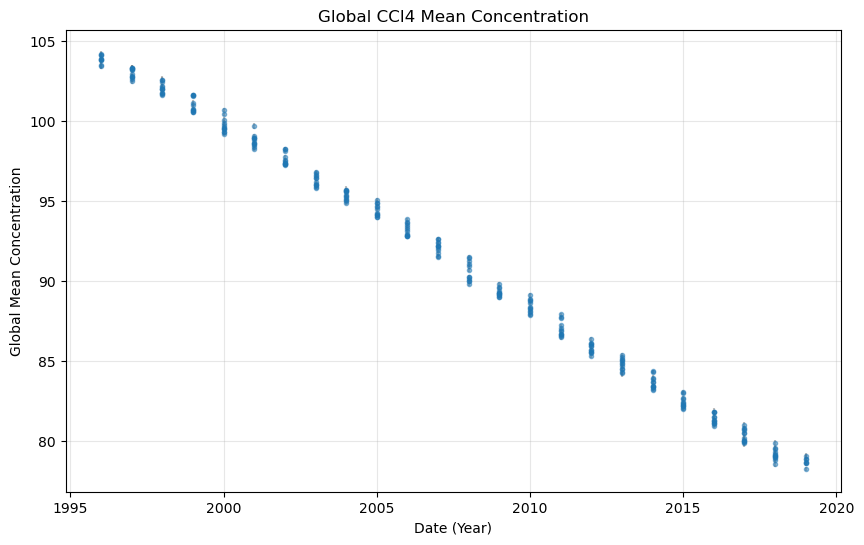

In [103]:
plt.figure(figsize=(10, 6))
plt.errorbar(x, y, yerr=y_err, fmt='o', markersize=3, 
             label='Observed Data', alpha=0.5, ecolor='gray')
plt.xlabel('Date (Year)')
plt.ylabel('Global Mean Concentration')
plt.title('Global CCl4 Mean Concentration')
plt.grid(True, alpha=0.3)

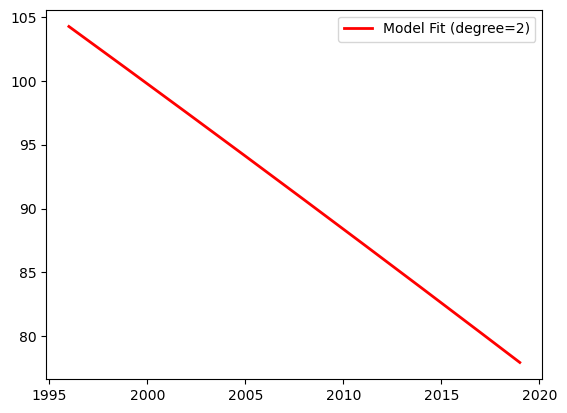

In [106]:
degree = 2
coeffs = np.polyfit(x, y, degree)
model_poly = np.poly1d(coeffs)
y_model = model_poly(x)

plt.plot(x, y_model, color='red', linewidth=2, label=f'Model Fit (degree={degree})')
plt.legend()
plt.show()

In [109]:
N = len(x)              
sigma = y_err           
chi_squared_terms = ((y_model - y)**2) / (sigma**2)
sum_chi_squared = np.sum(chi_squared_terms)

reduced_chi_squared = sum_chi_squared / (N - 1)

print("="*40)
print("LINEAR REGRESSION")
print("="*40)
print(f"Model used: Polynomial (Degree {degree})")
print(f"Number of data points (N): {N}")
print(f"Reduced Chi-Square: {reduced_chi_squared:.5f}")

if 0.5 <= reduced_chi_squared <= 1.5:
    print("The model fits the data well (Chi^2 is near 1).")
elif reduced_chi_squared > 1.5:
    print("The model is likely a poor fit (Chi^2 >> 1).")
else:
    print("The model might be overfitting (Chi^2 << 1).")

LINEAR REGRESSION
Model used: Polynomial (Degree 2)
Number of data points (N): 280
Reduced Chi-Square: 13.15167
The model is likely a poor fit (Chi^2 >> 1).
